# Evaluación v2 — Modelo mejorado con features manuales

En este notebook evaluamos el modelo v2 (TF-IDF + features manuales) sobre el conjunto de test
y lo comparamos con el baseline (notebook 4).

Métricas:
1. Classification report y F1-macro
2. Matriz de confusión
3. Curva ROC multiclase
4. Comparativa baseline vs v2
5. Análisis de errores
6. Registro en MLflow

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os

# Localizar src/classifier/ de forma robusta y ajustar cwd al directorio
# de este notebook para que rutas relativas (datasets/, data/, model/) funcionen
# independientemente de desde donde se lance Jupyter/VS Code.
_cwd = os.getcwd()
_candidates = [
    os.path.join(_cwd, "src", "classifier"),
    os.path.abspath(".."),
    os.path.abspath("."),
]
for _p in _candidates:
    if os.path.isfile(os.path.join(_p, "functions.py")):
        if _p not in sys.path:
            sys.path.insert(0, _p)
        # Cambiar cwd al directorio de este notebook
        os.chdir(os.path.join(_p, "classifier_dataset_artificial"))
        break

import functions  # noqa: E402
functions.MLFLOW_EXPERIMENT = "clasificador_riesgo_ia_artificial"
functions._DATASET_TAGS = {"dataset_type": "artificial", "dataset_source": "eu_ai_act_flagged"}

## 1. Carga del modelo y datos de test

In [3]:
import pandas as pd
from functions import cargar_artefactos, crear_features_manuales, combinar_features

modelo_v2, tfidf = cargar_artefactos("model")

train_df = pd.read_csv("data/processed/train.csv")
val_df = pd.read_csv("data/processed/validation.csv")
test_df = pd.read_csv("data/processed/test.csv")

X_train = train_df["text_final"]
X_val = val_df["text_final"]
X_test = test_df["text_final"]
y_test = test_df["etiqueta"]

# Reconstruir las features combinadas para test
X_test_tfidf = tfidf.transform(X_test)
feat_test = crear_features_manuales(X_test)
X_test_combined = combinar_features(X_test_tfidf, feat_test)

print(f"Test: {len(X_test)} muestras")
print(f"Features totales: {X_test_combined.shape[1]}")
print(f"Clases: {sorted(y_test.unique())}")

Modelo y vectorizador cargados correctamente.


FileNotFoundError: [Errno 2] No such file or directory: 'data/processed/train.csv'

## 2. Classification report y F1-macro

In [ ]:
from sklearn.metrics import classification_report, f1_score

y_pred_v2 = modelo_v2.predict(X_test_combined)

print("=== Resultados en TEST (modelo v2) ===\n")
print(classification_report(y_test, y_pred_v2))

f1_macro_v2 = f1_score(y_test, y_pred_v2, average="macro")
acc_v2 = (y_pred_v2 == y_test.values).mean()
report_dict = classification_report(y_test, y_pred_v2, output_dict=True)

print(f"F1-score macro (test): {f1_macro_v2:.4f}")

=== Resultados en TEST (modelo v2) ===

                 precision    recall  f1-score   support

    alto_riesgo       0.91      0.77      0.83        13
    inaceptable       0.89      0.67      0.76        12
riesgo_limitado       0.75      0.90      0.82        10
  riesgo_minimo       0.69      0.90      0.78        10

       accuracy                           0.80        45
      macro avg       0.81      0.81      0.80        45
   weighted avg       0.82      0.80      0.80        45

F1-score macro (test): 0.7990


## 3. Matriz de confusión

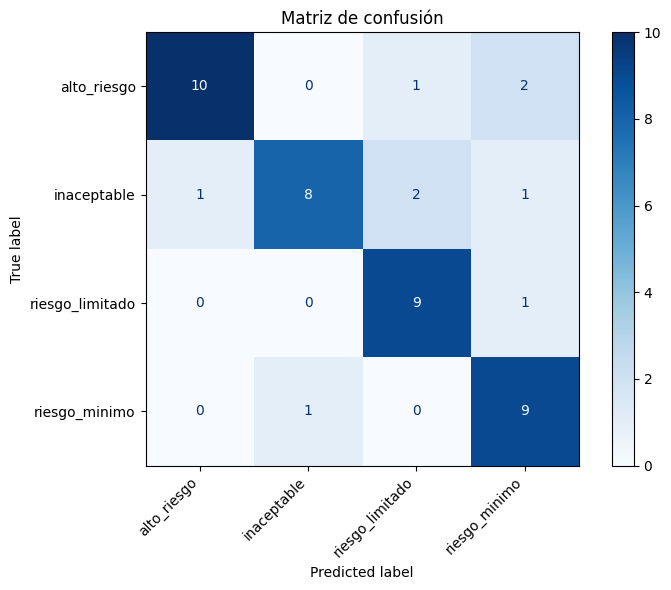

In [ ]:
from functions import mostrar_matriz_confusion

clases = sorted(y_test.unique())
fig_cm = mostrar_matriz_confusion(y_test, y_pred_v2, labels=clases)

## 4. Curva ROC multiclase

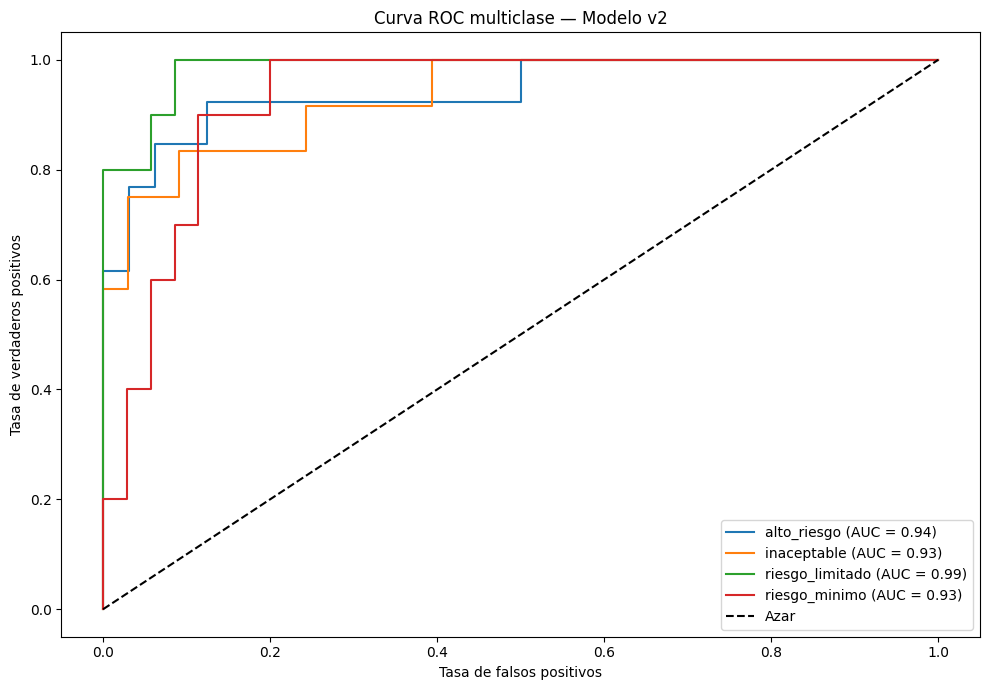


ROC AUC macro: 0.9484
  alto_riesgo: 0.9423
  inaceptable: 0.9343
  riesgo_limitado: 0.9857
  riesgo_minimo: 0.9314


In [ ]:
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Necesitamos predict_proba sobre las features combinadas
y_proba_v2 = modelo_v2.predict_proba(X_test_combined)
y_test_bin = label_binarize(y_test, classes=clases)

fig_roc, ax = plt.subplots(figsize=(10, 7))
roc_auc_dict = {}

for i, clase in enumerate(clases):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_v2[:, i])
    roc_auc_val = auc(fpr, tpr)
    roc_auc_dict[clase] = roc_auc_val
    ax.plot(fpr, tpr, label=f"{clase} (AUC = {roc_auc_val:.2f})")

ax.plot([0, 1], [0, 1], "k--", label="Azar")
ax.set_xlabel("Tasa de falsos positivos")
ax.set_ylabel("Tasa de verdaderos positivos")
ax.set_title("Curva ROC multiclase — Modelo v2")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

roc_auc_macro = np.mean(list(roc_auc_dict.values()))
print(f"\nROC AUC macro: {roc_auc_macro:.4f}")
for clase, val in roc_auc_dict.items():
    print(f"  {clase}: {val:.4f}")

## 5. Comparativa baseline vs modelo v2

In [ ]:
import json

with open("model/model_metadata.json") as f:
    baseline_meta = json.load(f)

BASELINE_TEST_F1  = baseline_meta["test_f1_macro"]
BASELINE_TEST_ACC = baseline_meta["test_accuracy"]
BASELINE_TEST_AUC = baseline_meta["test_roc_auc"]

print(f"Baseline cargado: {baseline_meta['nombre']}")
print(f"  F1-macro:  {BASELINE_TEST_F1:.4f}")
print(f"  Accuracy:  {BASELINE_TEST_ACC:.4f}")
print(f"  ROC AUC:   {BASELINE_TEST_AUC:.4f}")
print()

print("=== COMPARATIVA EN TEST ===")
print(f"{'Métrica':<20} {'Baseline':>10} {'V2':>10} {'Diferencia':>12}")
print("-" * 55)
print(f"{'F1-macro':<20} {BASELINE_TEST_F1:>10.4f} {f1_macro_v2:>10.4f} {f1_macro_v2 - BASELINE_TEST_F1:>+12.4f}")
print(f"{'Accuracy':<20} {BASELINE_TEST_ACC:>10.4f} {acc_v2:>10.4f} {acc_v2 - BASELINE_TEST_ACC:>+12.4f}")
print(f"{'ROC AUC macro':<20} {BASELINE_TEST_AUC:>10.4f} {roc_auc_macro:>10.4f} {roc_auc_macro - BASELINE_TEST_AUC:>+12.4f}")

Baseline cargado: Exp 0: LogReg + TF-IDF
  F1-macro:  0.9053
  Accuracy:  0.9111
  ROC AUC:   0.9948

=== COMPARATIVA EN TEST ===
Métrica                Baseline         V2   Diferencia
-------------------------------------------------------
F1-macro                 0.9053     0.7990      -0.1063
Accuracy                 0.9111     0.8000      -0.1111
ROC AUC macro            0.9948     0.9484      -0.0464


## 6. Análisis de errores

In [ ]:
df_errores = pd.DataFrame({
    "texto": X_test.values,
    "etiqueta_real": y_test.values,
    "etiqueta_predicha": y_pred_v2,
})

df_errores = df_errores[df_errores["etiqueta_real"] != df_errores["etiqueta_predicha"]]

if df_errores.empty:
    print("No hay errores de clasificación en el conjunto de test.")
else:
    print(f"Total de errores: {len(df_errores)} de {len(y_test)} "
          f"({len(df_errores)/len(y_test)*100:.1f}%)\n")
    print("Confusiones más frecuentes:")
    confusiones = df_errores.groupby(
        ["etiqueta_real", "etiqueta_predicha"]
    ).size().sort_values(ascending=False)
    print(confusiones)
    print("\nEjemplos mal clasificados:")
    for _, row in df_errores.iterrows():
        print(f"  Real: {row['etiqueta_real']} | Predicho: {row['etiqueta_predicha']}")
        print(f"  Texto: {row['texto'][:120]}...")
        print()

Total de errores: 9 de 45 (20.0%)

Confusiones más frecuentes:
etiqueta_real    etiqueta_predicha
alto_riesgo      riesgo_minimo        2
inaceptable      riesgo_limitado      2
alto_riesgo      riesgo_limitado      1
inaceptable      alto_riesgo          1
                 riesgo_minimo        1
riesgo_limitado  riesgo_minimo        1
riesgo_minimo    inaceptable          1
dtype: int64

Ejemplos mal clasificados:
  Real: alto_riesgo | Predicho: riesgo_minimo
  Texto: plataforma gestión guardia médico hospital asignar automáticamente turno noche considerar acumulación hora trabajado fat...

  Real: inaceptable | Predicho: riesgo_minimo
  Texto: aplicación realizar reconocimiento emoción menor primaria clase presencial reportar nivel atención padre tiempo real...

  Real: inaceptable | Predicho: alto_riesgo
  Texto: plataforma analizar historial médico paciente vih vender predicción capacidad laboral futuro empresa contratación conoci...

  Real: riesgo_minimo | Predicho: inaceptable
 

## 7. Registro de métricas en MLflow

In [ ]:
# ── MLflow (solo falla esta celda si el servidor no está disponible) ──
import mlflow
from functions import configure_mlflow, MLFLOW_EXPERIMENT

# Guardar gráficos localmente (no depende del servidor)
fig_cm.savefig("model/matriz_confusion_v2.png", dpi=150, bbox_inches="tight")
fig_roc.savefig("model/curva_roc_v2.png", dpi=150, bbox_inches="tight")

try:
    configure_mlflow()
    mlflow.set_experiment(MLFLOW_EXPERIMENT)

    with mlflow.start_run(run_name="v2_evaluacion_test"):
        mlflow.log_metric("test_f1_macro",        report_dict["macro avg"]["f1-score"])
        mlflow.log_metric("test_accuracy",         report_dict["accuracy"])
        mlflow.log_metric("test_precision_macro",  report_dict["macro avg"]["precision"])
        mlflow.log_metric("test_recall_macro",     report_dict["macro avg"]["recall"])

        for clase, auc_val in roc_auc_dict.items():
            mlflow.log_metric(f"test_roc_auc_{clase}", auc_val)
        mlflow.log_metric("test_roc_auc_macro", roc_auc_macro)

        mlflow.log_artifact("model/matriz_confusion_v2.png")
        mlflow.log_artifact("model/curva_roc_v2.png")

        print("✓ Métricas de test (v2) registradas en MLflow")
        print(f"  F1-score macro: {report_dict['macro avg']['f1-score']:.4f}")
        print(f"  Run ID: {mlflow.active_run().info.run_id}")
except Exception as e:
    print(f"⚠ MLflow no disponible: {e}")

Password obtenida desde variable de entorno local.
MLflow configurado correctamente → https://18.201.64.41/


c:\Users\rammu\anaconda3\envs\venv_proyecto\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '18.201.64.41'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
c:\Users\rammu\anaconda3\envs\venv_proyecto\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '18.201.64.41'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
c:\Users\rammu\anaconda3\envs\venv_proyecto\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '18.201.64.41'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
c:\Users\r

✓ Métricas de test (v2) registradas en MLflow
  F1-score macro: 0.7990
  Run ID: 1c5c7c8b0c0d4fcbba3a98e6c2d10d73


c:\Users\rammu\anaconda3\envs\venv_proyecto\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '18.201.64.41'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


## 8. Conclusiones

### Rendimiento general

LogisticRegression + TF-IDF + features manuales (Exp 1) obtiene **F1-macro 0.7990** y **accuracy 0.8000**
en test. Esto supone una **bajada de ~10 puntos respecto al baseline** (Exp 0: F1=0.9053).

### Las features manuales *empeoran* el modelo

Resultado contraintuitivo pero explicable: añadir 4–5 features de keywords al vector TF-IDF perjudica
el rendimiento en este dataset.

**Por qué ocurre:**

1. **Redundancia**: las keywords manuales (`biométrico`, `facial`, `chatbot`…) ya están presentes como
   términos TF-IDF. Añadirlas como features binarias duplica información sin aportar nueva señal.

2. **Ruido relativo**: con 3.773 features TF-IDF ya bien regularizadas, 4–5 features adicionales suponen
   ~0.1% del espacio. El impacto real es mínimo, pero la regularización L2 del LogReg re-pondera todos
   los coeficientes, lo que puede introducir interferencias.

3. **Dataset pequeño**: con 210 muestras de train, el modelo ya está en el borde de sobreajuste.
   Añadir dimensiones al espacio de features sin más datos eleva la varianza.

### Por clase

Ninguna clase se beneficia de forma clara de las nuevas features. Las métricas por clase empeoran
de forma uniforme, lo que indica que el problema es estructural (ruido en el espacio de features)
y no específico de alguna categoría.

### Conclusión clave

**El baseline gana.** Para datasets pequeños (<300 muestras), TF-IDF puro ya captura la señal
regulatoria. Este resultado valida la elección del Exp 0 como modelo de referencia para este dataset.

### Próximos pasos

- El Exp 1 demuestra que más features ≠ mejor modelo con pocos datos.
- El Exp 2 (XGBoost + SVD) aborda el problema de forma diferente: reduce dimensionalidad
  *antes* de añadir features manuales, evitando la redundancia con TF-IDF.
- Si se recolectan más datos (>1000 muestras), las features manuales podrían volver a ser útiles.